<a href="https://colab.research.google.com/github/AslesaLamsal/AI-and-Machine-Learning/blob/main/2407798_AslesaLamsal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2407798_AslesaLamsal

# Image Classification with Convolutional Neural Network.

 # What does the dataset represent? Provide a brief description.

The Skin Cancer Classification dataset consists of different types of skin lesions captured through dermatoscopic imaging. Skin lesions are abnormal growths or patches on the skin that can be either benign or malignant.

The dataset contains 9 classes covering a range of conditions from dangerous malignant cancers such as Melanoma, Basal Cell Carcinoma and Squamous Cell Carcinoma,
to benign conditions such as Nevus, Dermatofibroma and Seborrheic Keratosis.

# How many total images are in the dataset?

A training set consisting of approximately 900 images spread across 9 different categories was utilised to support the classification process.

The test set consists only of 27 images and is too small for any meaningful evaluation. The missing classes resulted in shifting to a validation split for all evaluations.

# What is the distribution of images across different classes?

The dataset is heavily imbalanced. Melanoma dominates with approximately
430 images (48%), followed by Squamous Cell Carcinoma with ~175 images (19.4%)
and Nevus with ~115 images (12.9%). Classes such as Dermatofibroma,
Vascular Lesion and Basal Cell Carcinoma have near-zero representation.
This imbalance causes the model to perform poorly on minority classes,
as seen in the VGG16 classification report where Seborrheic Keratosis
scored 0.00 F1-score.

#  How is the dataset split into training and validation sets? Justify your choice.


The training folder was split 80% training and 20% validation using
image_dataset_from_directory(validation_split=0.2, subset="both").
This is the standard split that gives the model enough data to learn
while reserving a meaningful portion to monitor generalisation and
detect overfitting during training.

# What preprocessing techniques (e.g., resizing, normalization) were applied?

Images were resized to 128×128 pixels for CNN models and 224×224 for VGG16.
Pixel values were normalised from [0, 255] to [0, 1] using
layers.Rescaling(1./255) embedded as the first layer inside each model.
This ensures consistent input dimensions and stable gradient updates during training.

# What data generators, if any, were used for preprocessing and augmentation?

tf.keras.utils.image_dataset_from_directory was used to load and batch
images directly from the folder structure. Labels were inferred automatically
from subdirectory names. Prefetching with AUTOTUNE was applied for
performance optimisation during training.
For augmentation, layers.RandomFlip("horizontal_and_vertical") was used
as a direct layer inside each model, applied only during training.

# If data augmentation was applied, provide visualizations of sample augmented images.

Yes, data augmentation was applied using layers.RandomFlip(horizontal_and_vertical)
embedded directly inside each model after the Rescaling layer.
Augmentation is only active during training and not during evaluation or inference.
Sample augmented images are visualised in the Data Augmentation code cell below.

# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Extract Dataset

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and Machine Learning/Coursework/Skin Cancer Classification-20260430T075306Z-3-001.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


#  Define Dataset Paths

In [ ]:
train_dir = "/content/data/Skin Cancer Classification/Train"
test_dir  = "/content/data/Skin Cancer Classification/Test"

print(f"Train directory : {train_dir}")
print(f"Test  directory : {test_dir}")

Train directory : /content/data/Skin Cancer Classification/Train
Test  directory : /content/data/Skin Cancer Classification/Test


# Importing all libraries

In [ ]:
import random, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image, UnidentifiedImageError
import os
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, Activation,
    GlobalAveragePooling2D, Input
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)


# Dataset Description & Class Names

In [ ]:
class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

NUM_CLASSES = len(class_names)

print(f"\nTotal number of classes: {NUM_CLASSES}")


Found 9 classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']

Total number of classes: 9


# Check for Corrupted Images

In [ ]:
corrupted_images = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, SyntaxError, UnidentifiedImageError):
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

# Print results
if corrupted_images:
    print(f"\nCorrupted Images Found and Removed: {len(corrupted_images)}")
else:
    print("No corrupted images found.")

Removed corrupted image: /content/data/Skin Cancer Classification/Train/actinic keratosis/ISIC_0026171.jpg
Removed corrupted image: /content/data/Skin Cancer Classification/Train/actinic keratosis/ISIC_0030730.jpg
Removed corrupted image: /content/data/Skin Cancer Classification/Train/actinic keratosis/ISIC_0027958.jpg
Removed corrupted image: /content/data/Skin Cancer Classification/Train/actinic keratosis/ISIC_0030036.jpg
Removed corrupted image: /content/data/Skin Cancer Classification/Train/actinic keratosis/ISIC_0029460.jpg
Removed corrupted image: /content/data/Skin Cancer Classification/Train/actinic keratosis/ISIC_0028076.jpg
Removed corrupted image: /content/data/Skin Cancer Classification/Train/actinic keratosis/ISIC_0025957.jpg
Removed corrupted image: /content/data/Skin Cancer Classification/Train/melanoma/ISIC_0010486.jpg
Removed corrupted image: /content/data/Skin Cancer Classification/Train/melanoma/ISIC_0000308.jpg
Removed corrupted image: /content/data/Skin Cancer Clas

# Class Distribution Analysis

In [ ]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print(f"{'Class Name':<30}{'Image Count':>10}")
for class_name, count in class_counts.items():
    print(f"{class_name:<30}{count:>10}")
print(f"{'TOTAL':<30}{sum(class_counts.values()):>10}")

Class Name                    Image Count
actinic keratosis                    107
basal cell carcinoma                   0
dermatofibroma                         0
melanoma                             431
nevus                                116
pigmented benign keratosis             0
seborrheic keratosis                  70
squamous cell carcinoma              174
vascular lesion                        0
TOTAL                                898


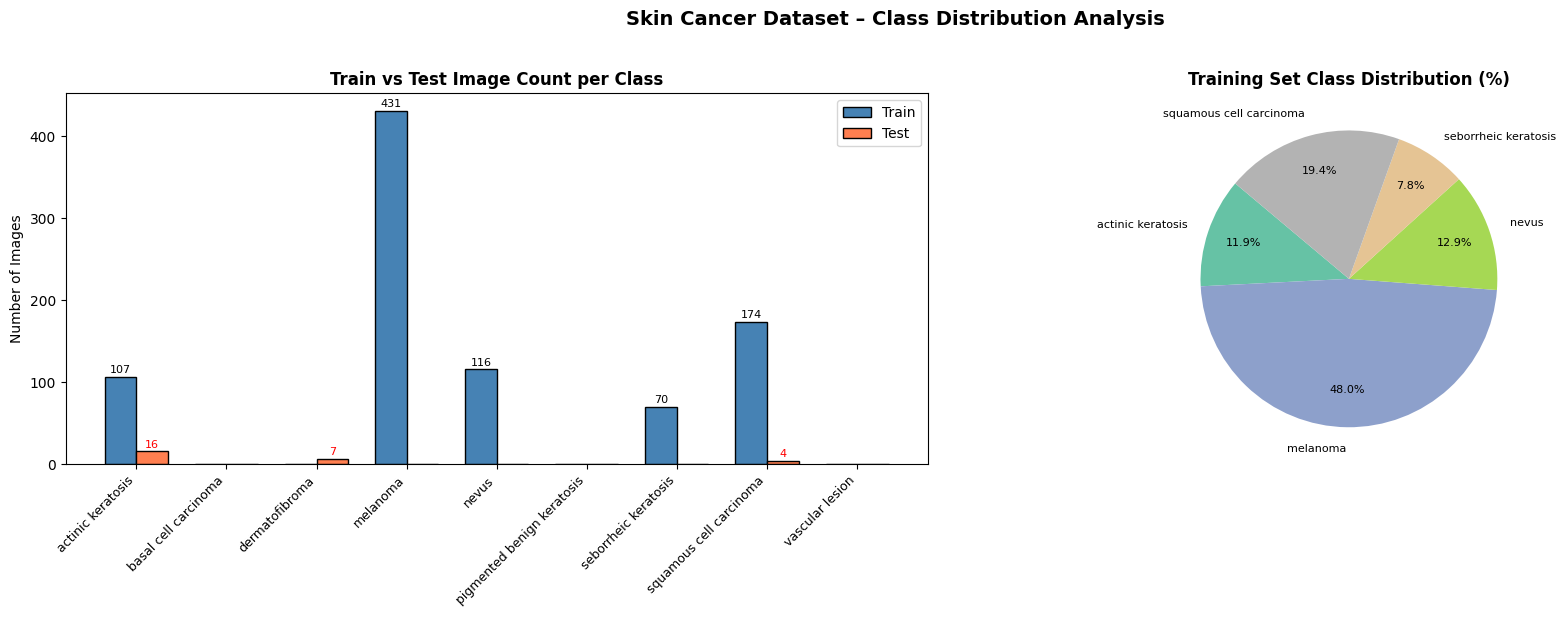

In [ ]:
test_counts = {}
for class_name in class_names:
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        test_counts[class_name] = len(images)

colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x = np.arange(NUM_CLASSES)
w = 0.35
train_vals = [class_counts.get(c, 0) for c in class_names]
test_vals  = [test_counts.get(c, 0)  for c in class_names]

b1 = axes[0].bar(x - w/2, train_vals, width=w, label='Train',
                 color='steelblue', edgecolor='black')
b2 = axes[0].bar(x + w/2, test_vals,  width=w, label='Test',
                 color='coral', edgecolor='black')

for bar in b1:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 2,
                     str(int(h)), ha='center', va='bottom', fontsize=8)
for bar in b2:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 2,
                     str(int(h)), ha='center', va='bottom', fontsize=8, color='red')

axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
axes[0].set_title('Train vs Test Image Count per Class', fontweight='bold')
axes[0].set_ylabel('Number of Images')
axes[0].legend()

filtered_counts = {k: v for k, v in class_counts.items() if v > 0}

def autopct_fmt(pct):
    return f'{pct:.1f}%' if pct >= 3 else ''

wedges, texts, autotexts = axes[1].pie(
    filtered_counts.values(),
    labels=filtered_counts.keys(),
    autopct=autopct_fmt,
    colors=plt.cm.Set2(np.linspace(0, 1, len(filtered_counts))),
    startangle=140,
    pctdistance=0.75,
    labeldistance=1.15
)
for text in texts:
    text.set_fontsize(8)
for autotext in autotexts:
    autotext.set_fontsize(8)

axes[1].set_title('Training Set Class Distribution (%)', fontweight='bold')

plt.suptitle('Skin Cancer Dataset – Class Distribution Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Visualise Sample Images

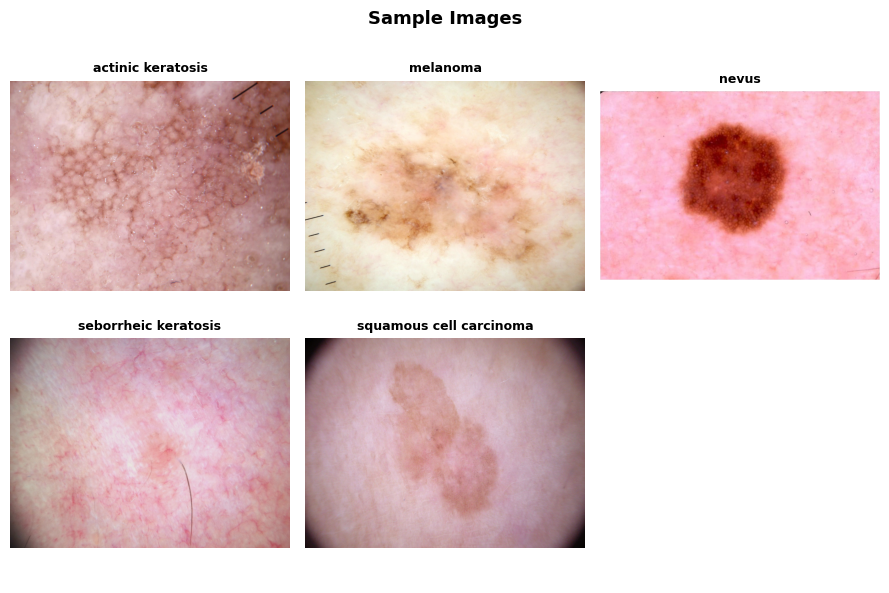

In [ ]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, 6))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i], fontsize=9, fontweight='bold')
        ax.axis('off')
    else:
        ax.axis('off')

plt.suptitle('Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Load And Preprocess Dataset (80/20 Split)

In [ ]:
# Image size and batch size
image_size  = (128, 128)
batch_size  = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)


dataset_class_names = train_ds.class_names
print(f"Class names: {dataset_class_names}")

for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 898 files belonging to 9 classes.
Using 719 files for training.
Using 179 files for validation.
Class names: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Images shape: (32, 128, 128, 3)
Labels shape: (32,)


# Data Augmentation

In [ ]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
]

print("Augmentation layers defined: RandomFlip horizontal and vertical")


Augmentation layers defined: RandomFlip horizontal and vertical


# Augmentation Visualisation

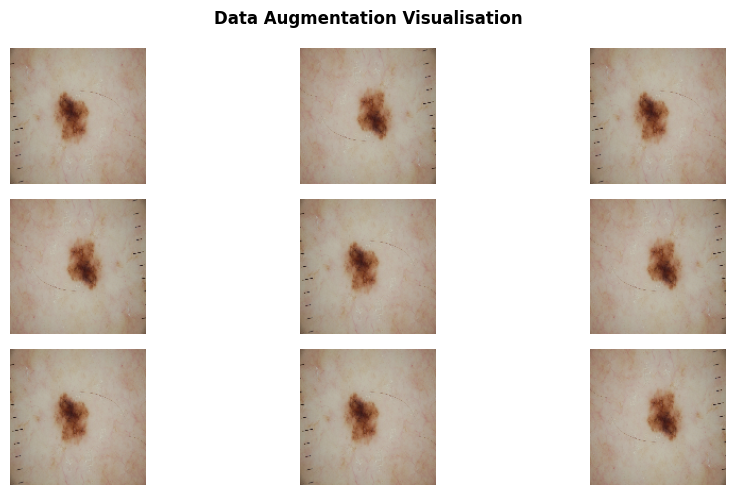

In [ ]:
plt.figure(figsize=(10, 5))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented = layers.RandomFlip("horizontal_and_vertical")(
                        tf.expand_dims(images[0], 0))
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented[0]).astype("uint8"))
        plt.axis("off")
plt.suptitle('Data Augmentation Visualisation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Build Baseline CNN (3 Conv + 3 FC Layers)

In [ ]:
input_shape = (128, 128, 3)

baseline_model = Sequential([
    layers.Input(shape=input_shape),
    layers.Rescaling(1./255),
    *data_augmentation_layers,

    # Conv Block 1 – 32 filters, kernel (3,3), ReLU
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    # Conv Block 2 – 64 filters, kernel (3,3), ReLU
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    # Conv Block 3 – 128 filters, kernel (3,3), ReLU
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),   # FC Layer 1
    Dense(128, activation='relu'),   # FC Layer 2
    Dense(64,  activation='relu'),   # FC Layer 3
    Dense(NUM_CLASSES, activation='softmax')
], name='Baseline_CNN')

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,849 (32.52 MB)

 Trainable params: 8,523,849 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

# Train BAseline Model

In [ ]:
checkpoint = ModelCheckpoint(
    'best_skin_cancer_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

t0 = time.time()

history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint, early_stop]
)
baseline_time = time.time() - t0
print(f"\nBaseline training time: {baseline_time:.1f}s ({baseline_time/60:.1f} mins)")

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.4055 - loss: 1.6862
Epoch 1: val_accuracy improved from None to 0.54190, saving model to best_skin_cancer_model.h5



Epoch 1: finished saving model to best_skin_cancer_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 460ms/step - accuracy: 0.4590 - loss: 1.5044 - val_accuracy: 0.5419 - val_loss: 1.1892
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.4981 - loss: 1.2239
Epoch 2: val_accuracy improved from 0.54190 to 0.65363, saving model to best_skin_cancer_model.h5



Epoch 2: finished saving model to best_skin_cancer_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 289ms/step - accuracy: 0.5299 - loss: 1.1514 - val_accuracy: 0.6536 - val_loss: 0.9786
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.6088 - loss: 0.9431
Epoch 3: val_accuracy did not improve from 0.65363
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.6078 - loss: 0.9604 - val_accuracy: 0.5251 - val_loss: 1.0489
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.6247 - loss: 0.9878
Epoch 4: val_accuracy did not improve from 0.65363
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step - accuracy: 0.6259 - loss: 0.9699 - val_accuracy: 0.6034 - val_loss: 0.9633
Epoch 5/50
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.5893 - loss: 0.9966
Epoch 5: val_accuracy did not improve from 0.65363
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 293ms/step - accuracy: 0.6273 - loss: 0.9363 - val_accuracy: 0.6425 - val_loss: 0.9408
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accura


Epoch 7: finished saving model to best_skin_cancer_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 286ms/step - accuracy: 0.6509 - loss: 0.8768 - val_accuracy: 0.6760 - val_loss: 0.8227
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.6497 - loss: 0.8205
Epoch 8: val_accuracy did not improve from 0.67598
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 331ms/step - accuracy: 0.6662 - loss: 0.8036 - val_accuracy: 0.6536 - val_loss: 0.8008
Epoch 9/50
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.6433 - loss: 0.8692
Epoch 9: val_accuracy did not improve from 0.67598
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.6662 - loss: 0.8552 - val_accuracy: 0.5978 - val_loss: 0.8359
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6863 - loss: 0.8207
Epoch 10: val_accuracy improved from 0.67598 to 0.68156, saving model to best_skin_cancer_model.h5



Epoch 10: finished saving model to best_skin_cancer_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 221ms/step - accuracy: 0.6690 - loss: 0.9068 - val_accuracy: 0.6816 - val_loss: 0.8001
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.6676 - loss: 0.7954
Epoch 11: val_accuracy did not improve from 0.68156
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 287ms/step - accuracy: 0.6954 - loss: 0.7753 - val_accuracy: 0.6536 - val_loss: 0.7739
Epoch 12/50
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.6867 - loss: 0.7109
Epoch 12: val_accuracy improved from 0.68156 to 0.71508, saving model to best_skin_cancer_model.h5



Epoch 12: finished saving model to best_skin_cancer_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 258ms/step - accuracy: 0.7038 - loss: 0.7103 - val_accuracy: 0.7151 - val_loss: 0.7442
Epoch 13/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7069 - loss: 0.7125
Epoch 13: val_accuracy did not improve from 0.71508
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 212ms/step - accuracy: 0.7274 - loss: 0.7019 - val_accuracy: 0.6872 - val_loss: 0.7287
Epoch 14/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.6905 - loss: 0.7580
Epoch 14: val_accuracy did not improve from 0.71508
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 350ms/step - accuracy: 0.6912 - loss: 0.7521 - val_accuracy: 0.6760 - val_loss: 0.7910
Epoch 15/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.7084 - loss: 0.6988
Epoch 15: val_accuracy did not improve from 0.71508
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step - accuracy: 0.7232 - loss: 0.6837 - val_accuracy: 0.6760 - val_loss: 0.7470
Epoch 16/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step 


Epoch 19: finished saving model to best_skin_cancer_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 221ms/step - accuracy: 0.7191 - loss: 0.7191 - val_accuracy: 0.7263 - val_loss: 0.7883
Epoch 20/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.7017 - loss: 0.6622
Epoch 20: val_accuracy did not improve from 0.72626
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 224ms/step - accuracy: 0.7371 - loss: 0.6139 - val_accuracy: 0.6927 - val_loss: 0.7955
Epoch 21/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.7906 - loss: 0.5195
Epoch 21: val_accuracy did not improve from 0.72626
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 272ms/step - accuracy: 0.7816 - loss: 0.5285 - val_accuracy: 0.6592 - val_loss: 1.0020
Epoch 22/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.7555 - loss: 0.6475
Epoch 22: val_accuracy did not improve from 0.72626
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 222ms/step - accuracy: 0.7330 - loss: 0.7182 - val_accuracy: 0.6927 - val_loss: 0.8813
Epoch 23/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step 

# Plot Training Curves

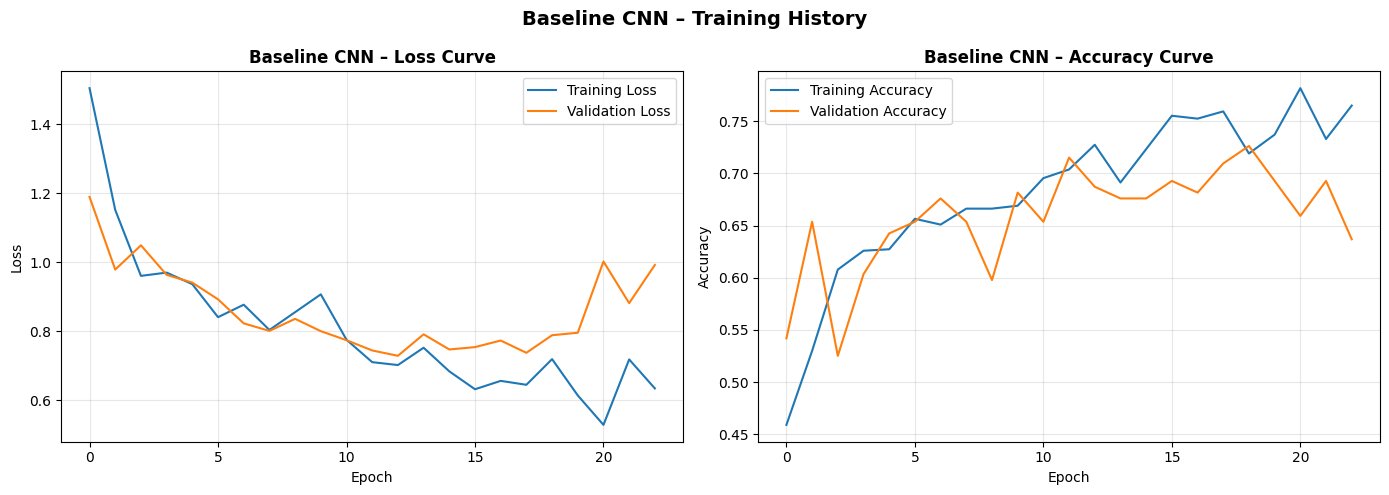

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'],     label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Baseline CNN – Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curve
axes[1].plot(history.history['accuracy'],     label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Baseline CNN – Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Baseline CNN – Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Train Baseline Model

In [ ]:
test_class_names = sorted(os.listdir(test_dir))
test_class_names = [c for c in test_class_names
                    if os.path.isdir(os.path.join(test_dir, c))]

print(f"Test class names : {test_class_names}")
print(f"Train class names: {dataset_class_names}")

Test class names : ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Train class names: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


In [ ]:
# Count test images per class
print("Test set image counts:")
print("=" * 40)
total_test = 0
for class_name in test_class_names:
    class_path = os.path.join(test_dir, class_name)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"{class_name:<35} {len(images)}")
    total_test += len(images)
print("=" * 40)
print(f"Total test images: {total_test}")

Test set image counts:
actinic keratosis                   16
basal cell carcinoma                0
dermatofibroma                      7
melanoma                            0
nevus                               0
pigmented benign keratosis          0
seborrheic keratosis                0
squamous cell carcinoma             4
vascular lesion                     0
Total test images: 27


# Evaluate Baseline Model

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.6872 - loss: 0.7287

Baseline CNN Val Loss    : 0.7287
Baseline CNN Val Accuracy: 0.6872 (68.72%)

Classification Report – Baseline CNN:
                         precision    recall  f1-score   support

      actinic keratosis       0.38      0.30      0.33        20
               melanoma       0.75      0.90      0.82        82
                  nevus       0.58      0.58      0.58        19
   seborrheic keratosis       0.00      0.00      0.00        14
squamous cell carcinoma       0.71      0.73      0.72        44

               accuracy                           0.69       179
              macro avg       0.48      0.50      0.49       179
           weighted avg       0.62      0.69      0.65       179



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


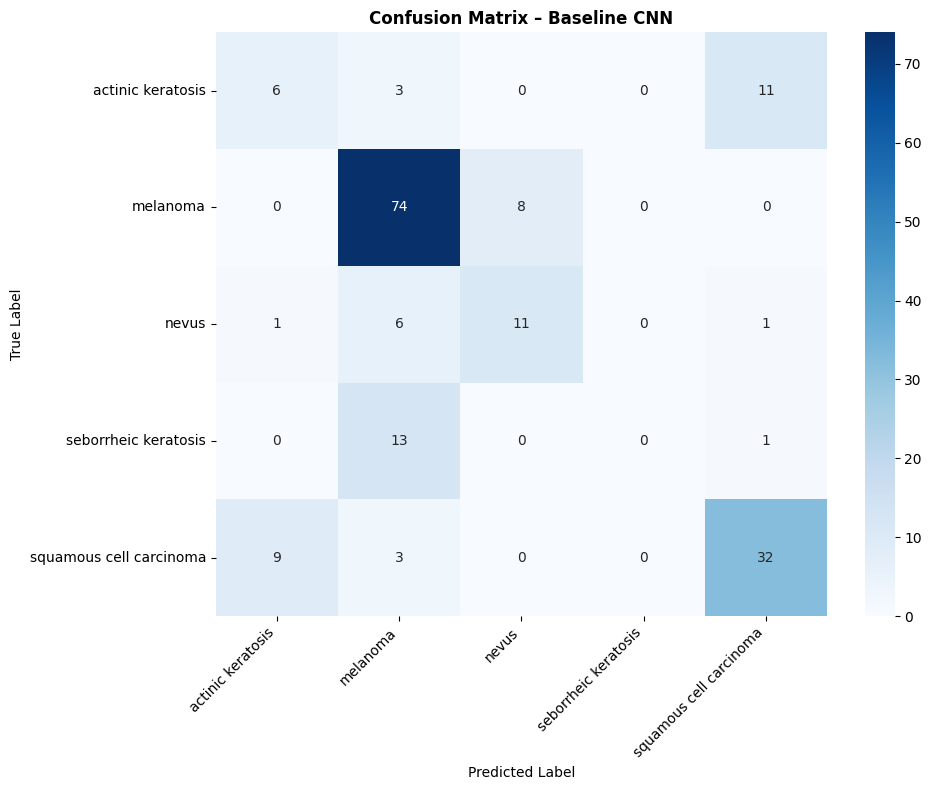

In [ ]:
# Evaluate on validation set
val_loss, val_acc = baseline_model.evaluate(val_ds)
print(f"\nBaseline CNN Val Loss    : {val_loss:.4f}")
print(f"Baseline CNN Val Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = baseline_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Only use classes that actually exist in the validation set
existing_labels = sorted(set(y_true))
existing_class_names = [dataset_class_names[i] for i in existing_labels]

print("\nClassification Report – Baseline CNN:")
print(classification_report(y_true, y_pred,
                             labels=existing_labels,
                             target_names=existing_class_names))

cm = confusion_matrix(y_true, y_pred, labels=existing_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=existing_class_names,
            yticklabels=existing_class_names)
plt.title('Confusion Matrix – Baseline CNN', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Save acc for final comparison
val_acc_baseline = val_acc

# Sample Image

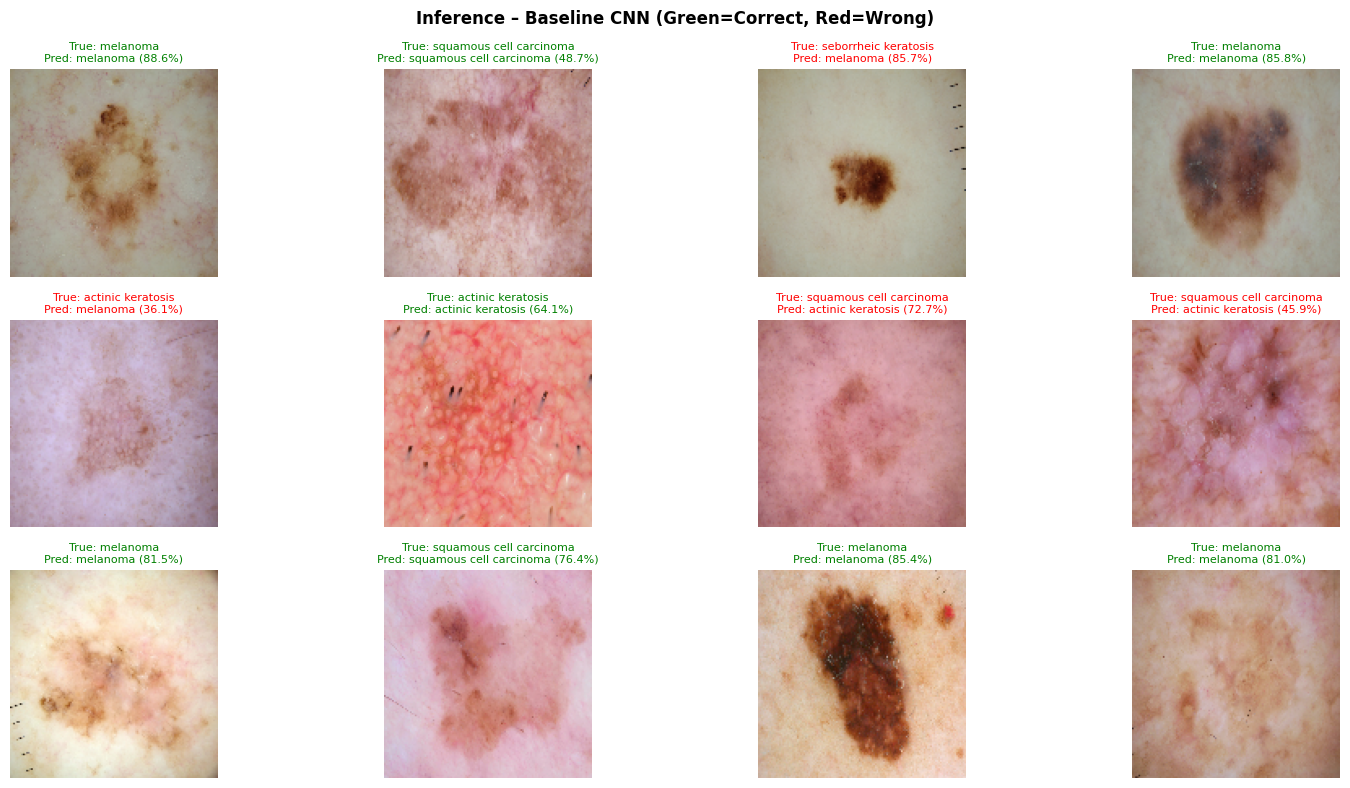

In [ ]:
for images, labels in val_ds:
    predictions = baseline_model.predict(images, verbose=0)
    pred_labels = np.argmax(predictions, axis=1)
    plt.figure(figsize=(16, 8))
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        true_lbl = dataset_class_names[labels[i].numpy()]
        pred_lbl = dataset_class_names[pred_labels[i]]
        conf     = predictions[i][pred_labels[i]] * 100
        color    = 'green' if true_lbl == pred_lbl else 'red'
        plt.title(f"True: {true_lbl}\nPred: {pred_lbl} ({conf:.1f}%)",
                  color=color, fontsize=8)
        plt.axis('off')
        if i == 11:
            break
    plt.suptitle('Inference – Baseline CNN (Green=Correct, Red=Wrong)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    break

#Save And Load BAseline Model

In [ ]:
baseline_model.save('baseline_skin_cancer_model.h5')
print("Model saved: baseline_skin_cancer_model.h5")

loaded_model = keras.models.load_model('baseline_skin_cancer_model.h5')
loss, acc = loaded_model.evaluate(val_ds, verbose=0)
print(f"Reloaded model – Val Loss: {loss:.4f} | Val Accuracy: {acc:.4f}")

Model saved: baseline_skin_cancer_model.h5


Reloaded model – Val Loss: 0.7287 | Val Accuracy: 0.6872


# Deeper CNN with BatchNorm

In [ ]:
deeper_model = Sequential([
    layers.Input(shape=input_shape),
    layers.Rescaling(1./255),
    *data_augmentation_layers,

    Conv2D(32, (3,3), padding='same'), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
    Conv2D(64, (3,3), padding='same'), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
    Conv2D(128,(3,3), padding='same'), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
    Conv2D(256,(3,3), padding='same'), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
    Conv2D(256,(3,3), padding='same'), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
    Conv2D(512,(3,3), padding='same'), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),

    Flatten(),
    Dense(512), BatchNormalization(), Activation('relu'), Dropout(0.5),
    Dense(256), BatchNormalization(), Activation('relu'), Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax')
], name='Deeper_CNN_BN_Dropout')

deeper_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
deeper_model.summary()

Model: "Deeper_CNN_BN_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,349,449 (12.78 MB)

 Trainable params: 3,345,417 (12.76 MB)

 Non-trainable params: 4,032 (15.75 KB)

# Train Deeper CNN (Adam)

Epoch 1/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.7191 - loss: 0.6345
Epoch 1: val_accuracy improved from None to 0.31844, saving model to best_deeper_model.h5



Epoch 1: finished saving model to best_deeper_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step - accuracy: 0.7288 - loss: 0.6446 - val_accuracy: 0.3184 - val_loss: 2.5228
Epoch 2/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.7162 - loss: 0.7072
Epoch 2: val_accuracy improved from 0.31844 to 0.44134, saving model to best_deeper_model.h5



Epoch 2: finished saving model to best_deeper_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 273ms/step - accuracy: 0.7455 - loss: 0.6220 - val_accuracy: 0.4413 - val_loss: 1.9987
Epoch 3/60
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.7916 - loss: 0.5395
Epoch 3: val_accuracy improved from 0.44134 to 0.52514, saving model to best_deeper_model.h5



Epoch 3: finished saving model to best_deeper_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 252ms/step - accuracy: 0.7691 - loss: 0.5826 - val_accuracy: 0.5251 - val_loss: 1.3162
Epoch 4/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.7931 - loss: 0.5711
Epoch 4: val_accuracy did not improve from 0.52514
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 213ms/step - accuracy: 0.7747 - loss: 0.6135 - val_accuracy: 0.4581 - val_loss: 1.9000
Epoch 5/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.7627 - loss: 0.5950
Epoch 5: val_accuracy improved from 0.52514 to 0.62011, saving model to best_deeper_model.h5



Epoch 5: finished saving model to best_deeper_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 319ms/step - accuracy: 0.7650 - loss: 0.6016 - val_accuracy: 0.6201 - val_loss: 0.9915
Epoch 6/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.7632 - loss: 0.5750
Epoch 6: val_accuracy did not improve from 0.62011
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 223ms/step - accuracy: 0.7733 - loss: 0.5513 - val_accuracy: 0.6089 - val_loss: 1.0752
Epoch 7/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.8117 - loss: 0.5019
Epoch 7: val_accuracy improved from 0.62011 to 0.63128, saving model to best_deeper_model.h5



Epoch 7: finished saving model to best_deeper_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 320ms/step - accuracy: 0.8025 - loss: 0.5133 - val_accuracy: 0.6313 - val_loss: 0.9124
Epoch 8/60
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8003 - loss: 0.4968
Epoch 8: val_accuracy improved from 0.63128 to 0.67039, saving model to best_deeper_model.h5



Epoch 8: finished saving model to best_deeper_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step - accuracy: 0.7955 - loss: 0.5324 - val_accuracy: 0.6704 - val_loss: 0.8837
Epoch 9/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.8108 - loss: 0.4884
Epoch 9: val_accuracy did not improve from 0.67039
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 294ms/step - accuracy: 0.8275 - loss: 0.4924 - val_accuracy: 0.6089 - val_loss: 1.1999
Epoch 10/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8544 - loss: 0.4106
Epoch 10: val_accuracy did not improve from 0.67039
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.8234 - loss: 0.4515 - val_accuracy: 0.6257 - val_loss: 0.9402
Epoch 11/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.8133 - loss: 0.4674
Epoch 11: val_accuracy did not improve from 0.67039
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - accuracy: 0.8011 - loss: 0.5133 - val_accuracy: 0.5196 - val_loss: 1.2301
Epoch 12/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accura


Epoch 14: finished saving model to best_deeper_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 217ms/step - accuracy: 0.8359 - loss: 0.4473 - val_accuracy: 0.6927 - val_loss: 1.0258
Epoch 15/60
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.8100 - loss: 0.4649
Epoch 15: val_accuracy did not improve from 0.69274
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 301ms/step - accuracy: 0.8206 - loss: 0.4330 - val_accuracy: 0.6201 - val_loss: 1.1820
Epoch 16/60
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8581 - loss: 0.3545
Epoch 16: val_accuracy did not improve from 0.69274
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 230ms/step - accuracy: 0.8609 - loss: 0.3565 - val_accuracy: 0.5084 - val_loss: 1.7286
Epoch 17/60
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.8685 - loss: 0.3565
Epoch 17: val_accuracy did not improve from 0.69274
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 278ms/step - accuracy: 0.8609 - loss: 0.3850 - val_accuracy: 0.6592 - val_loss: 1.1829
Epoch 18/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - acc

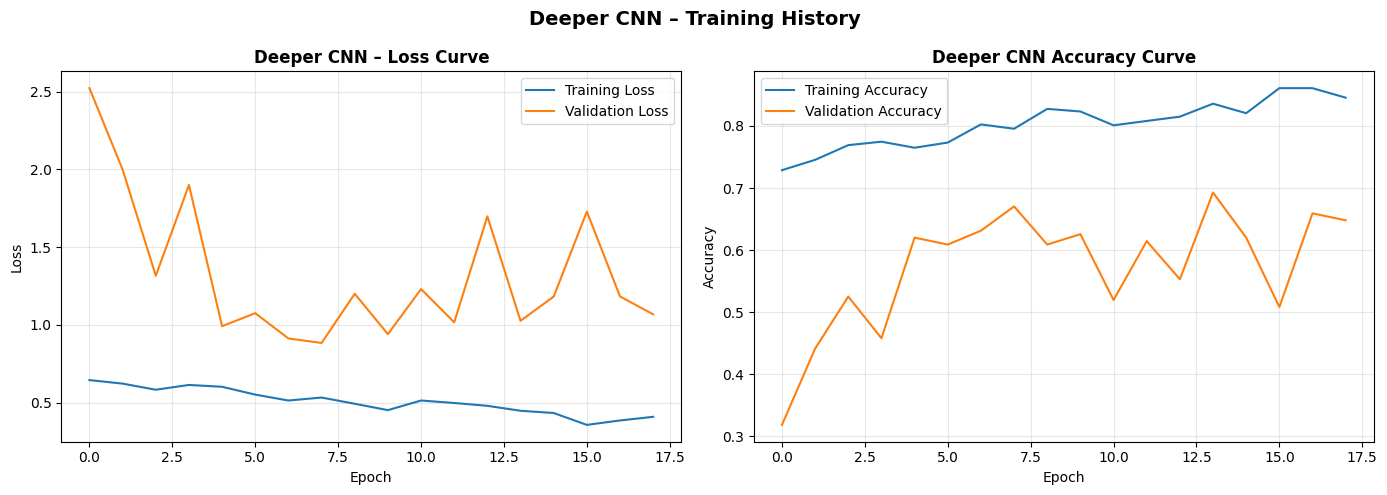

In [ ]:
checkpoint = ModelCheckpoint(
    'best_deeper_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

t1 = time.time()
deeper_history = deeper_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=[checkpoint, early_stop]
)
deeper_time = time.time() - t1

# Plot curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deeper_history.history['loss'],     label='Training Loss')
axes[0].plot(deeper_history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Deeper CNN – Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(deeper_history.history['accuracy'],     label='Training Accuracy')
axes[1].plot(deeper_history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Deeper CNN Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Deeper CNN – Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Train Deeper CNN (SGD) – Optimizer Comparison

Epoch 1/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.3717 - loss: 1.9372
Epoch 1: val_accuracy improved from None to 0.10615, saving model to best_deeper_sgd_model.h5



Epoch 1: finished saving model to best_deeper_sgd_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 563ms/step - accuracy: 0.4840 - loss: 1.5687 - val_accuracy: 0.1061 - val_loss: 12.0109
Epoch 2/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.5758 - loss: 1.1252
Epoch 2: val_accuracy improved from 0.10615 to 0.45810, saving model to best_deeper_sgd_model.h5



Epoch 2: finished saving model to best_deeper_sgd_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 276ms/step - accuracy: 0.5744 - loss: 1.1177 - val_accuracy: 0.4581 - val_loss: 5.6344
Epoch 3/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.6009 - loss: 1.0776
Epoch 3: val_accuracy did not improve from 0.45810
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - accuracy: 0.6064 - loss: 1.0637 - val_accuracy: 0.1397 - val_loss: 1.8266
Epoch 4/60
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.5575 - loss: 1.0454
Epoch 4: val_accuracy did not improve from 0.45810
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 293ms/step - accuracy: 0.5897 - loss: 1.0097 - val_accuracy: 0.3575 - val_loss: 1.6132
Epoch 5/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.6193 - loss: 0.9520
Epoch 5: val_accuracy improved from 0.45810 to 0.55866, saving model to best_deeper_sgd_model.h5



Epoch 5: finished saving model to best_deeper_sgd_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - accuracy: 0.6259 - loss: 0.9606 - val_accuracy: 0.5587 - val_loss: 1.3282
Epoch 6/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.6212 - loss: 0.8678
Epoch 6: val_accuracy did not improve from 0.55866
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 253ms/step - accuracy: 0.6314 - loss: 0.8836 - val_accuracy: 0.2458 - val_loss: 2.7468
Epoch 7/60
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.6254 - loss: 0.8736
Epoch 7: val_accuracy did not improve from 0.55866
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 257ms/step - accuracy: 0.6412 - loss: 0.8570 - val_accuracy: 0.3631 - val_loss: 1.6966
Epoch 8/60
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.6752 - loss: 0.8459
Epoch 8: val_accuracy did not improve from 0.55866
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 222ms/step - accuracy: 0.6606 - loss: 0.8774 - val_accuracy: 0.4916 - val_loss: 1.4919
Epoch 9/60
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accurac


Epoch 9: finished saving model to best_deeper_sgd_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 306ms/step - accuracy: 0.6328 - loss: 0.8676 - val_accuracy: 0.5698 - val_loss: 1.2253
Epoch 10/60
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.6884 - loss: 0.7630
Epoch 10: val_accuracy improved from 0.56983 to 0.63687, saving model to best_deeper_sgd_model.h5



Epoch 10: finished saving model to best_deeper_sgd_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - accuracy: 0.6801 - loss: 0.8013 - val_accuracy: 0.6369 - val_loss: 1.1199
Epoch 11/60
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.6822 - loss: 0.7549
Epoch 11: val_accuracy did not improve from 0.63687
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 297ms/step - accuracy: 0.6759 - loss: 0.7936 - val_accuracy: 0.6201 - val_loss: 1.1936
Epoch 12/60
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.6635 - loss: 0.7793
Epoch 12: val_accuracy did not improve from 0.63687
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - accuracy: 0.6940 - loss: 0.7570 - val_accuracy: 0.5587 - val_loss: 1.2071
Epoch 13/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6650 - loss: 0.7935
Epoch 13: val_accuracy did not improve from 0.63687
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 221ms/step - accuracy: 0.6745 - loss: 0.7736 - val_accuracy: 0.4581 - val_loss: 1.3193
Epoch 14/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step -


Epoch 19: finished saving model to best_deeper_sgd_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 306ms/step - accuracy: 0.6898 - loss: 0.7521 - val_accuracy: 0.6536 - val_loss: 0.8486
Epoch 20/60
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.7005 - loss: 0.7142
Epoch 20: val_accuracy did not improve from 0.65363
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 202ms/step - accuracy: 0.7038 - loss: 0.7154 - val_accuracy: 0.3743 - val_loss: 1.4582
Epoch 21/60
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.7066 - loss: 0.6947
Epoch 21: val_accuracy did not improve from 0.65363
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 296ms/step - accuracy: 0.7232 - loss: 0.6948 - val_accuracy: 0.5140 - val_loss: 1.4511
Epoch 22/60
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7438 - loss: 0.6437
Epoch 22: val_accuracy did not improve from 0.65363
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 208ms/step - accuracy: 0.7204 - loss: 0.6871 - val_accuracy: 0.5084 - val_loss: 2.2184
Epoch 23/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step -

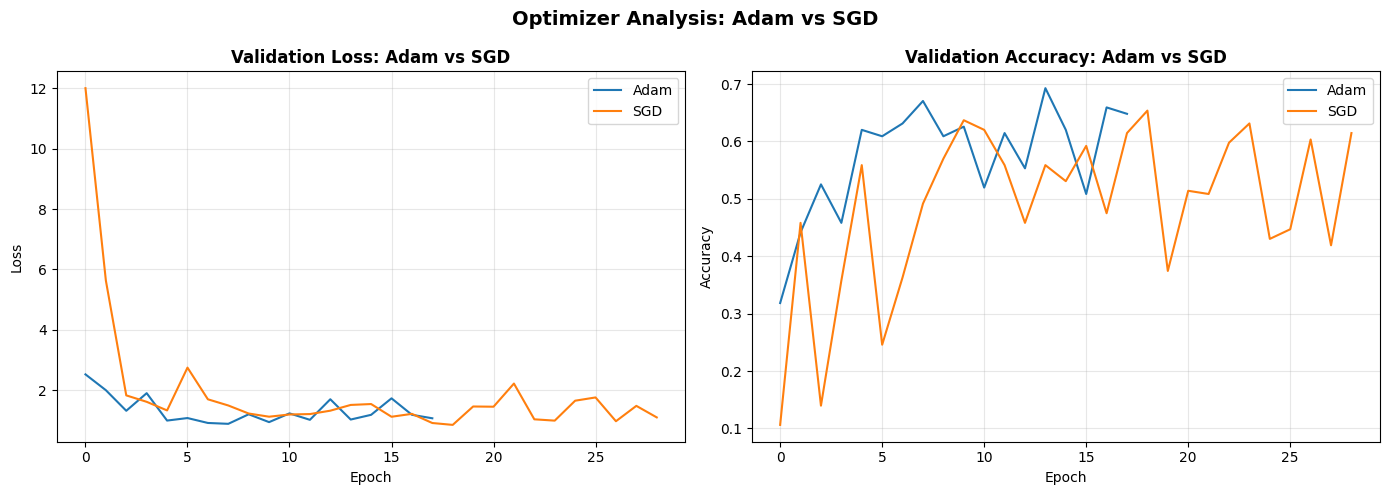

In [ ]:
deeper_model_sgd = Sequential([
    layers.Input(shape=input_shape),
    layers.Rescaling(1./255),
    *data_augmentation_layers,

    # Conv Block 1
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2)),

    # Conv Block 2
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2)),

    # Conv Block 3
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2)),

    # Conv Block 4
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2)),

    # Conv Block 5
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2)),

    # Conv Block 6
    Conv2D(512, (3, 3), padding='same', activation=None),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    # FC Layer 1
    Dense(512), BatchNormalization(), Activation('relu'), Dropout(0.5),

    # FC Layer 2
    Dense(256), BatchNormalization(), Activation('relu'), Dropout(0.4),

    # Output Layer
    Dense(NUM_CLASSES, activation='softmax')
], name='Deeper_CNN_SGD')

# Compile with SGD
deeper_model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_sgd = ModelCheckpoint(
    'best_deeper_sgd_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop_sgd = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

sgd_history = deeper_model_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=[checkpoint_sgd, early_stop_sgd]
)

# Optimizer comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deeper_history.history['val_loss'], label='Adam')
axes[0].plot(sgd_history.history['val_loss'],    label='SGD')
axes[0].set_title('Validation Loss: Adam vs SGD', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(deeper_history.history['val_accuracy'], label='Adam')
axes[1].plot(sgd_history.history['val_accuracy'],    label='SGD')
axes[1].set_title('Validation Accuracy: Adam vs SGD', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Optimizer Analysis: Adam vs SGD', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Evaluate Deeper Models

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.6704 - loss: 0.8837
Deeper CNN (Adam) – Val Loss: 0.8837 | Val Accuracy: 0.6704
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.6536 - loss: 0.8486
Deeper CNN (SGD)  – Val Loss: 0.8486 | Val Accuracy: 0.6536

Classification Report – Deeper CNN (Adam):
                         precision    recall  f1-score   support

      actinic keratosis       0.75      0.15      0.25        20
               melanoma       0.67      0.88      0.76        82
                  nevus       0.64      0.47      0.55        19
   seborrheic keratosis       0.20      0.07      0.11        14
squamous cell carcinoma       0.71      0.80      0.75        44

               accuracy                           0.67       179
              macro avg       0.60      0.47      0.48       179
           weighted avg       0.65      0.67      0.63       179



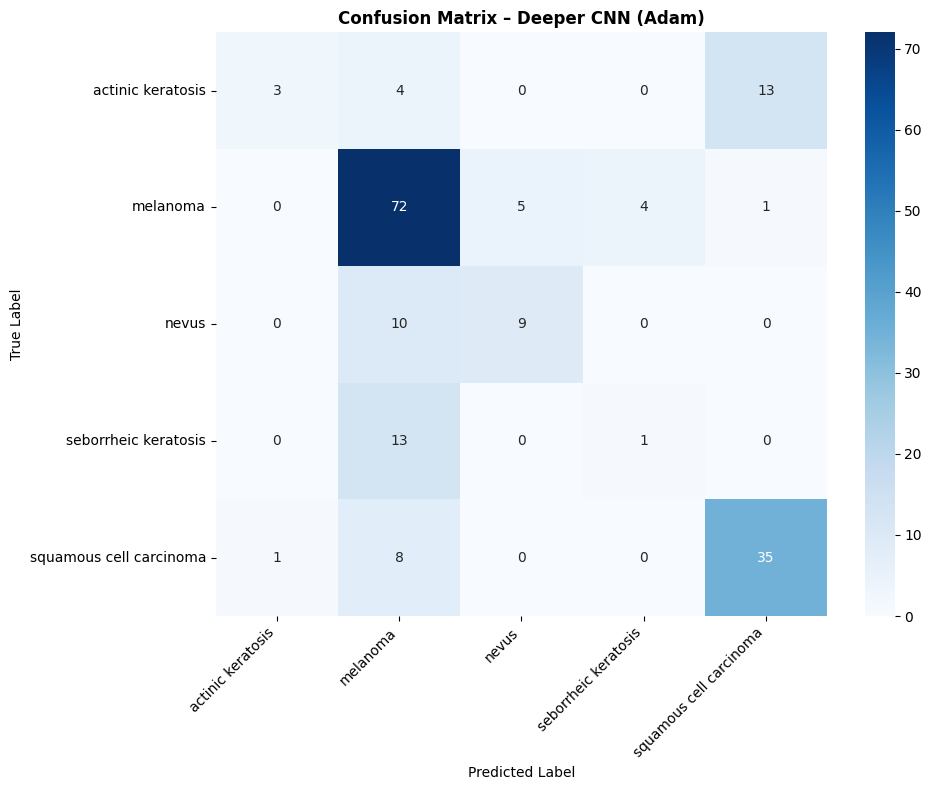

In [ ]:
d_loss, d_acc = deeper_model.evaluate(val_ds)
print(f"Deeper CNN (Adam) – Val Loss: {d_loss:.4f} | Val Accuracy: {d_acc:.4f}")

d_loss_sgd, d_acc_sgd = deeper_model_sgd.evaluate(val_ds)
print(f"Deeper CNN (SGD)  – Val Loss: {d_loss_sgd:.4f} | Val Accuracy: {d_acc_sgd:.4f}")

y_true2, y_pred2 = [], []
for images, labels in val_ds:
    preds = deeper_model.predict(images, verbose=0)
    y_pred2.extend(np.argmax(preds, axis=1))
    y_true2.extend(labels.numpy())
y_true2 = np.array(y_true2)
y_pred2 = np.array(y_pred2)

existing_labels = sorted(set(y_true2))
existing_class_names = [dataset_class_names[i] for i in existing_labels]

print("\nClassification Report – Deeper CNN (Adam):")
print("=" * 60)
print(classification_report(y_true2, y_pred2,
                             labels=existing_labels,
                             target_names=existing_class_names))

cm2 = confusion_matrix(y_true2, y_pred2, labels=existing_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=existing_class_names,
            yticklabels=existing_class_names)
plt.title('Confusion Matrix – Deeper CNN (Adam)', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Ablation Study: Remove Dropout

In [ ]:
ablation_model = Sequential([
    layers.Input(shape=input_shape),
    layers.Rescaling(1./255),
    *data_augmentation_layers,

    Conv2D(32, (3,3), padding='same'), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
    Conv2D(64, (3,3), padding='same'), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
    Conv2D(128,(3,3), padding='same'), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
    Conv2D(256,(3,3), padding='same'), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
    Conv2D(256,(3,3), padding='same'), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
    Conv2D(512,(3,3), padding='same'), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),


    Flatten(),
    Dense(512), BatchNormalization(), Activation('relu'),
    Dense(256), BatchNormalization(), Activation('relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='Ablation_No_Dropout')

ablation_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Ablation Study: Training WITHOUT Dropout...")
ablation_history = ablation_model.fit(
    train_ds, epochs=20, validation_data=val_ds,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                             restore_best_weights=True, verbose=1)]
)

abl_loss, abl_acc = ablation_model.evaluate(val_ds, verbose=0)
print(f"\nAblation (No Dropout)   – Val Accuracy: {abl_acc:.4f}")
print(f"Deeper + Dropout (Adam) – Val Accuracy: {d_acc:.4f}")
print(f"Dropout improvement     : {(d_acc - abl_acc)*100:+.2f}%")
print("\nConclusion: Removing Dropout increases overfitting (train acc >> val acc).")

Ablation Study: Training WITHOUT Dropout...
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 553ms/step - accuracy: 0.5104 - loss: 1.4831 - val_accuracy: 0.3296 - val_loss: 1.9054
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 293ms/step - accuracy: 0.6175 - loss: 0.9352 - val_accuracy: 0.4581 - val_loss: 1.5058
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - accuracy: 0.6426 - loss: 0.8820 - val_accuracy: 0.5084 - val_loss: 1.4367
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 224ms/step - accuracy: 0.6565 - loss: 0.8805 - val_accuracy: 0.4581 - val_loss: 1.4225
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 310ms/step - accuracy: 0.6857 - loss: 0.7821 - val_accuracy: 0.4581 - val_loss: 1.4625
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - accuracy: 0.6537 - loss: 0.8443 - val_accuracy: 0.0782 - val_loss: 2.0634
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 291ms/step - accuracy: 0.7093 - loss: 0.7427 - val_accuracy: 0.2737 - val_loss: 1.5062
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 207ms/step - accur

# Save And Load Deeper Model

In [ ]:
deeper_model.save('/content/deeper_cnn_skin_cancer.keras')
print("Model saved: /content/deeper_cnn_skin_cancer.keras")

loaded_deeper = keras.models.load_model(
    '/content/deeper_cnn_skin_cancer.keras'
)
loss2, acc2 = loaded_deeper.evaluate(val_ds, verbose=0)
print(f"Reloaded model – Val Loss: {loss2:.4f} | Val Accuracy: {acc2:.4f}")

Model saved: /content/deeper_cnn_skin_cancer.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 36 variables whereas the saved optimizer has 70 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Reloaded model – Val Loss: 0.8837 | Val Accuracy: 0.6704


# Transfer Learning – Load VGG16

In [ ]:
train_ds_vgg, val_ds_vgg = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=(224, 224),
    batch_size=batch_size,
)

train_ds_vgg = train_ds_vgg.prefetch(AUTOTUNE)
val_ds_vgg   = val_ds_vgg.prefetch(AUTOTUNE)

print("Datasets loaded at 224x224 for VGG16")

# Load the VGG16 model pre-trained on ImageNet, without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

print(f"VGG16 loaded. Total layers: {len(base_model.layers)}")

Found 898 files belonging to 9 classes.
Using 719 files for training.
Using 179 files for validation.
Datasets loaded at 224x224 for VGG16
VGG16 loaded. Total layers: 19


# Freeze VGG16 Layers (Feature Extraction)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

print(f"All {len(base_model.layers)} VGG16 layers frozen.")
print("Only the new classification head will be trained.")

All 19 VGG16 layers frozen.
Only the new classification head will be trained.


# Add Custom Classification Head

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(NUM_CLASSES, activation='softmax')(x)

vgg_model = Model(inputs=base_model.input, outputs=x, name='VGG16_Transfer_Learning')

# Compile the model
vgg_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



# Summary

In [ ]:
vgg_model.summary()

Model: "VGG16_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,769,417 (60.16 MB)

 Trainable params: 1,054,729 (4.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

# Train VGG16

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.3800 - loss: 2.6563
Epoch 1: val_accuracy improved from None to 0.50838, saving model to best_vgg_model.h5



Epoch 1: finished saving model to best_vgg_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 531ms/step - accuracy: 0.4437 - loss: 2.2897 - val_accuracy: 0.5084 - val_loss: 1.4354
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.5533 - loss: 1.4320
Epoch 2: val_accuracy improved from 0.50838 to 0.63687, saving model to best_vgg_model.h5



Epoch 2: finished saving model to best_vgg_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 331ms/step - accuracy: 0.5549 - loss: 1.3705 - val_accuracy: 0.6369 - val_loss: 1.1309
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.5807 - loss: 1.1595
Epoch 3: val_accuracy improved from 0.63687 to 0.68156, saving model to best_vgg_model.h5



Epoch 3: finished saving model to best_vgg_model.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 252ms/step - accuracy: 0.5897 - loss: 1.1139 - val_accuracy: 0.6816 - val_loss: 0.9544
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.6702 - loss: 0.8674
Epoch 4: val_accuracy did not improve from 0.68156
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 320ms/step - accuracy: 0.6676 - loss: 0.8987 - val_accuracy: 0.6592 - val_loss: 0.9925
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.6895 - loss: 0.7843
Epoch 5: val_accuracy did not improve from 0.68156
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 241ms/step - accuracy: 0.7024 - loss: 0.7793 - val_accuracy: 0.6425 - val_loss: 0.9649
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7111 - loss: 0.7871
Epoch 6: val_accuracy did not improve from 0.68156
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 237ms/step - accuracy: 0.7232 - loss: 0.7679 - val_accuracy: 0.6313 - val_loss: 1.0091
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.7

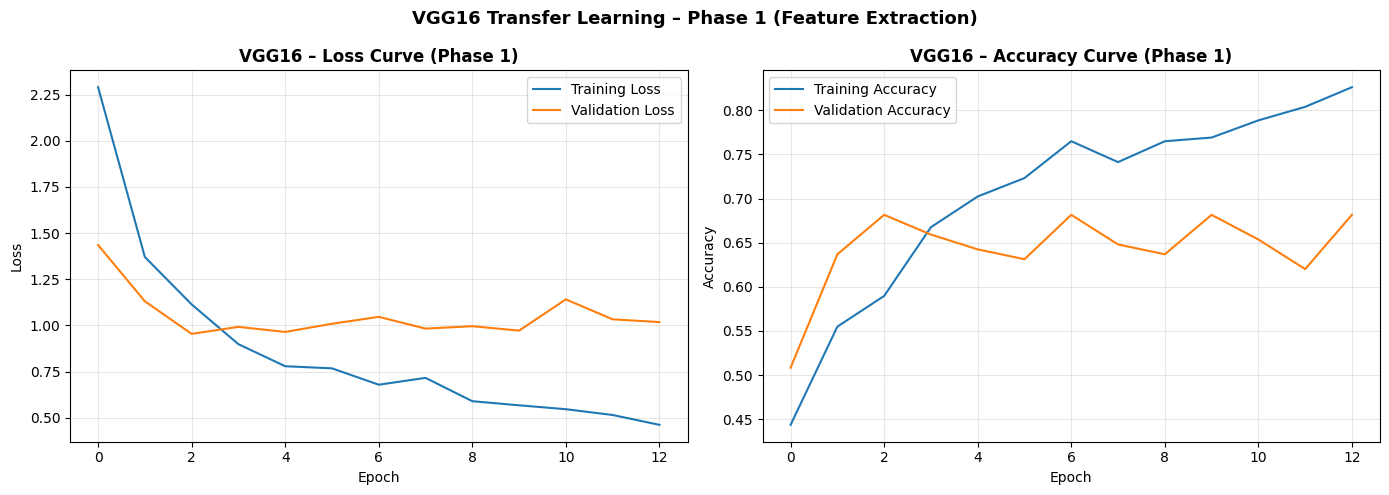

In [ ]:
checkpoint_vgg = ModelCheckpoint(
    'best_vgg_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop_vgg = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
t2 = time.time()
vgg_history = vgg_model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=50,
    callbacks=[checkpoint_vgg, early_stop_vgg]
)
vgg_time = time.time() - t2

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(vgg_history.history['loss'],     label='Training Loss')
axes[0].plot(vgg_history.history['val_loss'], label='Validation Loss')
axes[0].set_title('VGG16 – Loss Curve (Phase 1)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(vgg_history.history['accuracy'],     label='Training Accuracy')
axes[1].plot(vgg_history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('VGG16 – Accuracy Curve (Phase 1)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('VGG16 Transfer Learning – Phase 1 (Feature Extraction)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Evaluate VGG16 Transfer Learning

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.6816 - loss: 0.9544

VGG16 Val Loss    : 0.9544
VGG16 Val Accuracy: 0.6816 (68.16%)

Classification Report – VGG16 Transfer Learning:
                         precision    recall  f1-score   support

      actinic keratosis       0.77      0.50      0.61        20
               melanoma       0.67      0.85      0.75        82
                  nevus       0.71      0.53      0.61        19
   seborrheic keratosis       0.00      0.00      0.00        14
squamous cell carcinoma       0.71      0.73      0.72        44

               accuracy                           0.68       179
              macro avg       0.57      0.52      0.54       179
           weighted avg       0.64      0.68      0.65       179



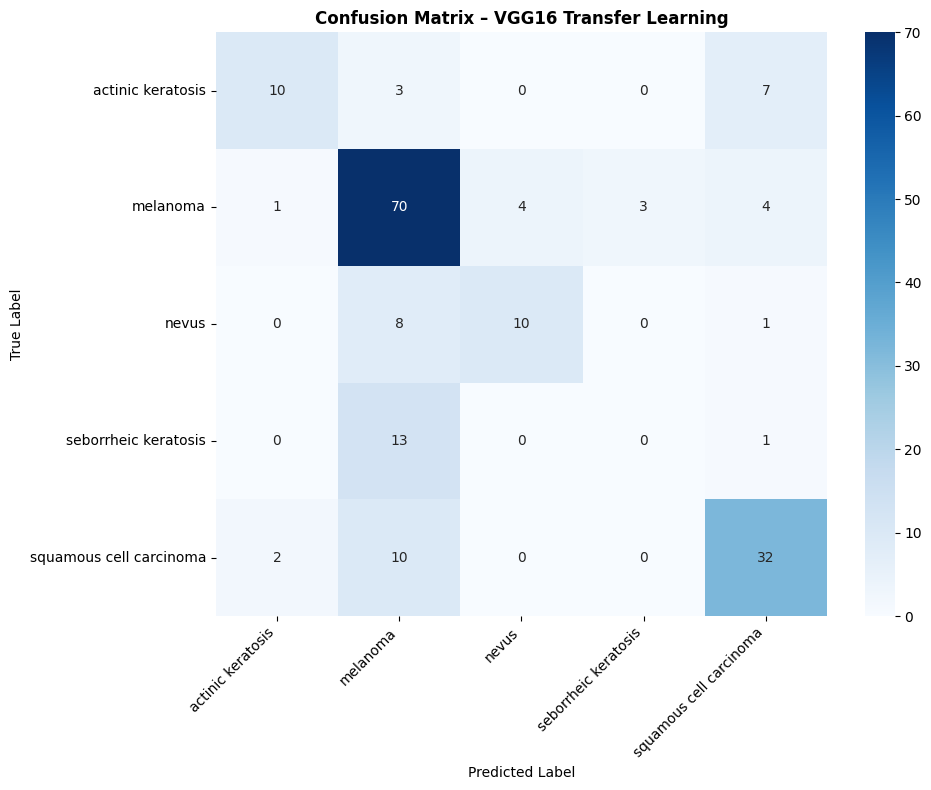

In [ ]:
vgg_loss, vgg_acc = vgg_model.evaluate(val_ds_vgg)
print(f"\nVGG16 Val Loss    : {vgg_loss:.4f}")
print(f"VGG16 Val Accuracy: {vgg_acc:.4f} ({vgg_acc*100:.2f}%)")

y_true_vgg, y_pred_vgg = [], []
for images, labels in val_ds_vgg:
    preds = vgg_model.predict(images, verbose=0)
    y_pred_vgg.extend(np.argmax(preds, axis=1))
    y_true_vgg.extend(labels.numpy())
y_true_vgg = np.array(y_true_vgg)
y_pred_vgg = np.array(y_pred_vgg)

existing_labels_vgg = sorted(set(y_true_vgg))
existing_class_names_vgg = [dataset_class_names[i] for i in existing_labels_vgg]

print("\nClassification Report – VGG16 Transfer Learning:")
print(classification_report(y_true_vgg, y_pred_vgg,
                             labels=existing_labels_vgg,
                             target_names=existing_class_names_vgg))

cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg, labels=existing_labels_vgg)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues',
            xticklabels=existing_class_names_vgg,
            yticklabels=existing_class_names_vgg)
plt.title('Confusion Matrix – VGG16 Transfer Learning', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Fine-Tuning Phase 2 (Unfreeze block5)

In [ ]:
for layer in base_model.layers:
    if 'block5' in layer.name:
        layer.trainable = True
        print(f"Unfrozen: {layer.name}")

vgg_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

vgg_history_ft = vgg_model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1)
    ]
)

Unfrozen: block5_conv1
Unfrozen: block5_conv2
Unfrozen: block5_conv3
Unfrozen: block5_pool
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 515ms/step - accuracy: 0.6704 - loss: 0.8656 - val_accuracy: 0.6592 - val_loss: 0.9346
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 326ms/step - accuracy: 0.7191 - loss: 0.7324 - val_accuracy: 0.6648 - val_loss: 0.9262
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 260ms/step - accuracy: 0.7385 - loss: 0.7119 - val_accuracy: 0.6536 - val_loss: 0.9283
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 289ms/step - accuracy: 0.7441 - loss: 0.6752 - val_accuracy: 0.6816 - val_loss: 0.8854
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 383ms/step - accuracy: 0.7622 - loss: 0.6478 - val_accuracy: 0.6480 - val_loss: 0.8887
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 250ms/step - accuracy: 0.8053 - loss: 0.5630 - val_accuracy: 0.6872 - val_loss: 0.8901
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 281ms/step - accuracy: 0.7942 - loss: 0.5652 - val_accuracy: 0.6816 - val_loss: 0.9047
Epoch 8/20

# Save & Load VGG16 Model

In [ ]:
vgg_model.save('vgg16_transfer_skin_cancer.h5')
print("Model saved: vgg16_transfer_skin_cancer.h5")

loaded_vgg = keras.models.load_model(
    'vgg16_transfer_skin_cancer.h5'
)

loss3, acc3 = loaded_vgg.evaluate(val_ds_vgg, verbose=0)
print(f"Reloaded model – Val Loss: {loss3:.4f} | Val Accuracy: {acc3:.4f}")

Model saved: vgg16_transfer_skin_cancer.h5


Reloaded model – Val Loss: 0.8701 | Val Accuracy: 0.7207


# Final Comparison: All Models

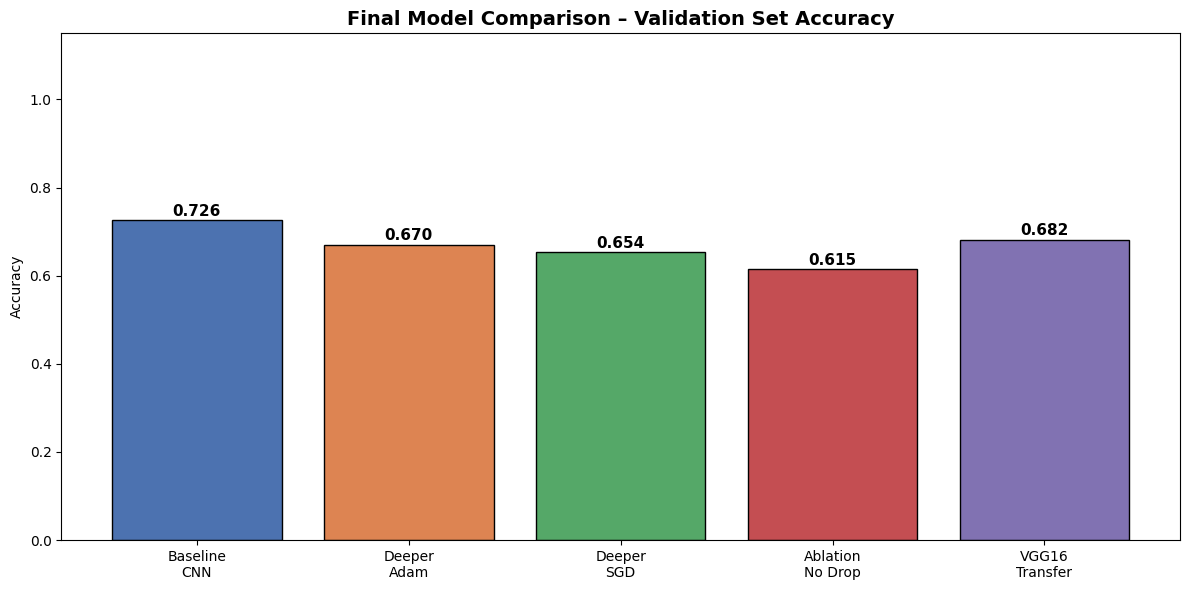


Best model   : Baseline CNN
Val Accuracy : 0.7263 (72.63%)

Did Transfer Learning outperform training from scratch?
  NO  – Best scratch model (0.7263) >= VGG16 (0.6816)
           FULL METRICS – Accuracy, Precision, Recall, F1-Score            
Model                                Accuracy  Precision   Recall       F1
Baseline CNN                           0.6872     0.6206   0.6872   0.6500
Deeper CNN (Adam)                      0.6704     0.6515   0.6704   0.6281
Deeper CNN (SGD)                       0.6536     0.6076   0.6536   0.6204
Ablation: No Dropout                   0.6145     0.6337   0.6145   0.5996
VGG16 Transfer Learning                0.7207     0.6813   0.7207   0.6961


In [ ]:
def get_preds(model, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)

y_true_b,   y_pred_b   = get_preds(baseline_model,   val_ds)
y_true_d,   y_pred_d   = get_preds(deeper_model,     val_ds)
y_true_sgd, y_pred_sgd = get_preds(deeper_model_sgd, val_ds)
y_true_abl, y_pred_abl = get_preds(ablation_model,   val_ds)
y_true_vgg, y_pred_vgg = get_preds(vgg_model,        val_ds_vgg)

def compute_metrics(y_true, y_pred):
    acc  = np.mean(y_true == y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return acc, prec, rec, f1

acc_b,   prec_b,   rec_b,   f1_b   = compute_metrics(y_true_b,   y_pred_b)
acc_d,   prec_d,   rec_d,   f1_d   = compute_metrics(y_true_d,   y_pred_d)
acc_sgd, prec_sgd, rec_sgd, f1_sgd = compute_metrics(y_true_sgd, y_pred_sgd)
acc_abl, prec_abl, rec_abl, f1_abl = compute_metrics(y_true_abl, y_pred_abl)
acc_vgg, prec_vgg, rec_vgg, f1_vgg = compute_metrics(y_true_vgg, y_pred_vgg)

val_acc = max(history.history['val_accuracy'])

model_labels = ['Baseline\nCNN', 'Deeper\nAdam', 'Deeper\nSGD',
                'Ablation\nNo Drop', 'VGG16\nTransfer']
accuracies   = [val_acc, d_acc, d_acc_sgd, abl_acc, vgg_acc]
colors_bar   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

plt.figure(figsize=(12, 6))
bars = plt.bar(model_labels, accuracies, color=colors_bar, edgecolor='black')
plt.title('Final Model Comparison – Validation Set Accuracy',
          fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1.15)
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

best_idx = int(np.argmax(accuracies))
print(f"\nBest model   : {model_labels[best_idx].replace(chr(10), ' ')}")
print(f"Val Accuracy : {accuracies[best_idx]:.4f} ({accuracies[best_idx]*100:.2f}%)")

scratch_best = max(val_acc, d_acc, d_acc_sgd)
print(f"\nDid Transfer Learning outperform training from scratch?")
if vgg_acc > scratch_best:
    print(f"  YES – VGG16 ({vgg_acc:.4f}) > Best scratch model ({scratch_best:.4f})")
else:
    print(f"  NO  – Best scratch model ({scratch_best:.4f}) >= VGG16 ({vgg_acc:.4f})")

print(f"{'FULL METRICS – Accuracy, Precision, Recall, F1-Score':^75}")
print(f"{'Model':<35} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print(f"{'Baseline CNN':<35} {acc_b:>9.4f} {prec_b:>10.4f} {rec_b:>8.4f} {f1_b:>8.4f}")
print(f"{'Deeper CNN (Adam)':<35} {acc_d:>9.4f} {prec_d:>10.4f} {rec_d:>8.4f} {f1_d:>8.4f}")
print(f"{'Deeper CNN (SGD)':<35} {acc_sgd:>9.4f} {prec_sgd:>10.4f} {rec_sgd:>8.4f} {f1_sgd:>8.4f}")
print(f"{'Ablation: No Dropout':<35} {acc_abl:>9.4f} {prec_abl:>10.4f} {rec_abl:>8.4f} {f1_abl:>8.4f}")
print(f"{'VGG16 Transfer Learning':<35} {acc_vgg:>9.4f} {prec_vgg:>10.4f} {rec_vgg:>8.4f} {f1_vgg:>8.4f}")

# Training Time Summary

In [ ]:
print(f"{'Model':<25} {'Time':>10}")
print(f"{'Baseline CNN':<25} {baseline_time/60:>8.1f}m")
print(f"{'Deeper CNN (Adam)':<25} {deeper_time/60:>8.1f}m")
print(f"{'VGG16 Transfer':<25} {vgg_time/60:>8.1f}m")
print("Hardware: Google Colab with GPU acceleration")

Model                           Time
Baseline CNN                   2.8m
Deeper CNN (Adam)              2.3m
VGG16 Transfer                 2.0m
Hardware: Google Colab with GPU acceleration
